# Deep Learning model for smoothing of PSD noisy curve, estimation of peaks and their frequency ranges.

__COLAB notebook.__ _(everything in it so it can run on colab)_

----------------------------------------------------------------------------------

__Goal:__ return clean PSD, peak and peak frequency interval from noisy PSD.

__Model:__ Unet based Neural Network

----------------------------------------------------------------------------------

The notebook focuses on:
- How to preprocess input data before entering model.
- Which losses to select
- Inference on real data and simulated data


In [ ]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import scipy.signal as signal
#%matplotlib tk
import matplotlib.pyplot as plt

In [ ]:
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Classes and Functions

### Helpers

In [ ]:
def to_numpy(tensor):
    return tensor.detach().cpu().numpy().squeeze()

### Dataset Conversion

In [ ]:
def convert_masks_to_target_structures(masks_array, sigma=2.0):
    """
    Converts 2D mask array [N, 2, n_freqs] into targets for Keypoint U-Net:
      - Channel 0: Center binary mask -> 1D Gaussian Heatmap Target [N, 1, n_freqs]
      - Channel 1: Interval binary mask -> Dense Width Targets [N, 2, n_freqs]
    """
    N, _, n_freqs = masks_array.shape
    x_axis = np.arange(n_freqs)

    target_heatmaps = np.zeros((N, 1, n_freqs), dtype=np.float32)
    target_widths   = np.zeros((N, 2, n_freqs), dtype=np.float32)  # [Left_Width, Right_Width]
    peak_masks      = np.zeros((N, 1, n_freqs), dtype=np.float32)  # Active across full peak regions

    for i in range(N):
        center_mask   = masks_array[i, 0]   # Channel 0
        interval_mask = masks_array[i, 1]   # Channel 1

        # Locate peak center indices (where center_mask > 0.5)
        peak_indices = np.where(center_mask > 0.5)[0]

        # 1. Generate 1D Gaussian Heatmap for Peak Head
        for p_idx in peak_indices:
            gaussian = np.exp(-((x_axis - p_idx) ** 2) / (2 * (sigma ** 2)))
            target_heatmaps[i, 0] = np.maximum(target_heatmaps[i, 0], gaussian)

        # 2. Extract Left/Right Interval Widths (DENSE REGRESSION MAPS)
        for p_idx in peak_indices:
            # Step left to measure interval start
            left_bound = p_idx
            while left_bound > 0 and interval_mask[left_bound - 1] > 0.5:
                left_bound -= 1

            # Step right to measure interval end
            right_bound = p_idx
            while right_bound < n_freqs - 1 and interval_mask[right_bound + 1] > 0.5:
                right_bound += 1

            # Populate DENSE offset maps for ALL bins within interval
            for x in range(left_bound, right_bound + 1):
                target_widths[i, 0, x] = float(x - left_bound)   # Distance to left boundary
                target_widths[i, 1, x] = float(right_bound - x)  # Distance to right boundary
                peak_masks[i, 0, x]    = 1.0                    # Mask active across entire peak

    return (
        torch.tensor(target_heatmaps, dtype=torch.float32),
        torch.tensor(target_widths, dtype=torch.float32),
        torch.tensor(peak_masks, dtype=torch.float32)
    )

class ConvertedKeypointPSDDataset(Dataset):
    """
    Dataset class that loads your existing NPZ file format:
    log_noisy_{split}, log_clean_{split}, masks_{split}
    """
    def __init__(self, filepath="psd_dataset_masks.npz", split="train", sigma=2.0):
        assert split in ["train", "val", "test"]
        print(f"Loading split '{split}' from {filepath}...")

        data = np.load(filepath, allow_pickle=True)
        self.f = data["f"]

        log_noisy_data = data[f"log_noisy_{split}"]
        log_clean_data = data[f"log_clean_{split}"]
        masks_data     = data[f"masks_{split}"]       # Shape: [N, 2, n_freqs]

        self.log_noisy = torch.tensor(log_noisy_data, dtype=torch.float32)
        self.log_clean = torch.tensor(log_clean_data, dtype=torch.float32)

        # Enforce 3D shapes [N, 1, n_freqs]
        if self.log_noisy.ndim == 2:
            self.log_noisy = self.log_noisy.unsqueeze(1)
        if self.log_clean.ndim == 2:
            self.log_clean = self.log_clean.unsqueeze(1)

        # Convert 2D masks into continuous Keypoint Targets
        self.target_heatmap, self.target_width, self.peak_mask = convert_masks_to_target_structures(
            masks_data, sigma=sigma
        )
        print(f" -> Successfully loaded & converted {len(self.log_noisy)} samples.")

    def __len__(self):
        return len(self.log_noisy)

    def __getitem__(self, idx):
        return {
            "noisy_psd":      self.log_noisy[idx],      # Input: [1, n_freqs]
            "clean_psd":      self.log_clean[idx],      # Head 1 Target: [1, n_freqs]
            "target_heatmap": self.target_heatmap[idx], # Head 2 Target: [1, n_freqs]
            "target_width":   self.target_width[idx],   # Head 3 Target: [2, n_freqs]
            "peak_mask":      self.peak_mask[idx]       # Mask for Loss: [1, n_freqs]
        }

### Model architecture

Model based on standard convolution layer.

In [ ]:
class ConvBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.GELU(),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.GELU()
        )
    def forward(self, x):
        return self.block(x)

# class ConvBlock1D(nn.Module):
#     def __init__(self, in_c, out_c):
#         super().__init__()
#         self.block = nn.Sequential(
#             nn.Conv1d(in_c, out_c, kernel_size=15, padding=7),
#             nn.BatchNorm1d(out_c),
#             nn.GELU(),
#             nn.Conv1d(out_c, out_c, kernel_size=15, padding=7),
#             nn.BatchNorm1d(out_c),
#             nn.GELU(),
#         )

#     def forward(self, x):
#         return self.block(x)

class MultiTaskUNet1D(nn.Module):
    def __init__(self, in_channels=1, base_filters=32):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(in_channels, base_filters)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = ConvBlock1D(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = ConvBlock1D(base_filters * 2, base_filters * 4)

        # Shared Decoder
        self.up2 = nn.ConvTranspose1d(base_filters * 4, base_filters * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock1D(base_filters * 4, base_filters * 2)

        self.up1 = nn.ConvTranspose1d(base_filters * 2, base_filters, kernel_size=2, stride=2)
        self.dec1 = ConvBlock1D(base_filters * 2, base_filters)

        # --- Head 1: Denoising Head (Clean Curve Reconstruction) ---
        self.head_denoise = nn.Sequential(
            nn.Conv1d(base_filters, base_filters // 2, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv1d(base_filters // 2, 1, kernel_size=1)
        )

        # --- Head 2: Peak Center Heatmap Head ---
        self.head_heatmap = nn.Sequential(
            nn.Conv1d(base_filters, base_filters // 2, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv1d(base_filters // 2, 1, kernel_size=1)
        )

        # --- Head 3: Interval / Bandwidth Width Head ---
        self.head_width = nn.Sequential(
            nn.Conv1d(base_filters, base_filters // 2, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv1d(base_filters // 2, 2, kernel_size=1), # 2 channels: [left_width, right_width]
            nn.ReLU()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        d2 = self.up2(e3)
        # Handle odd length padding mismatches from transposed convolution
        if d2.shape[-1] != e2.shape[-1]:
            d2 = F.interpolate(d2, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-1] != e1.shape[-1]:
            d1 = F.interpolate(d1, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        clean_psd     = self.head_denoise(d1)
        heatmap_logits = self.head_heatmap(d1)
        widths         = self.head_width(d1)

        return clean_psd, heatmap_logits, widths

Model with some convolution layers replaced by residual convolution.

In [ ]:
class ResConvBlock1D(nn.Module):
    def __init__(self, in_c, out_c, kernel_size=3, padding=1, drop_prob=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_c, out_c, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_c),
            nn.GELU(),
            nn.Dropout1d(p=drop_prob),  # Drop full feature channels
            nn.Conv1d(out_c, out_c, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_c),
        )
        self.shortcut = (
            nn.Conv1d(in_c, out_c, kernel_size=1)
            if in_c != out_c
            else nn.Identity()
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.block(x) + self.shortcut(x))


class ResMultiTaskUNet1D(nn.Module):
    """
    Multi-Task 1D UNet Architecture:
    - Backbone: Residual 1D UNet with 3 Encoder stages and 2 Decoder stages.
    - Head 1 (Denoise): Reconstructs clean PSD curve (1 channel output).
    - Head 2 (Heatmap): Predicts peak center probability logits (1 channel output).
    - Head 3 (Width): Predicts left & right peak widths (2 channel output, Softplus activation).
    """
    def __init__(self, in_channels=1, base_filters=32):
        super().__init__()

        # -----------------------------------------------------------------
        # ENCODER (Downsampling Path)
        # -----------------------------------------------------------------
        self.enc1 = ResConvBlock1D(in_channels, base_filters)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = ResConvBlock1D(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool1d(2)

        # Bottleneck
        self.enc3 = ResConvBlock1D(base_filters * 2, base_filters * 4)

        # -----------------------------------------------------------------
        # DECODER (Upsampling Path)
        # -----------------------------------------------------------------
        self.up2 = nn.ConvTranspose1d(
            base_filters * 4, base_filters * 2, kernel_size=2, stride=2
        )
        self.dec2 = ResConvBlock1D(base_filters * 4, base_filters * 2)

        self.up1 = nn.ConvTranspose1d(
            base_filters * 2, base_filters, kernel_size=2, stride=2
        )
        self.dec1 = ResConvBlock1D(base_filters * 2, base_filters)

        # -----------------------------------------------------------------
        # TASK HEADS (Divergent Predictions)
        # -----------------------------------------------------------------
        # Head 1: PSD Denoising Head
        self.head_denoise = nn.Sequential(
            nn.Conv1d(base_filters, base_filters // 2, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Dropout1d(p=0.1),
            nn.Conv1d(base_filters // 2, 1, kernel_size=1)
        )

        # Head 2: Peak Center Heatmap Head
        self.head_heatmap = nn.Sequential(
            nn.Conv1d(base_filters, base_filters // 2, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Dropout1d(p=0.1),
            nn.Conv1d(base_filters // 2, 1, kernel_size=1)
        )

        # Head 3: Peak Width Estimation Head
        self.head_width = nn.Sequential(
            nn.Conv1d(base_filters, base_filters // 2, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Dropout1d(p=0.1),
            nn.Conv1d(base_filters // 2, 2, kernel_size=1),
            nn.Softplus()
        )

    def forward(self, x):
        # --- Encoder Pass ---
        e1 = self.enc1(x)               # Shape: [B, base_filters, N]
        e2 = self.enc2(self.pool1(e1))  # Shape: [B, base_filters*2, N/2]
        e3 = self.enc3(self.pool2(e2))  # Shape: [B, base_filters*4, N/4]

        # --- Decoder Pass Stage 2 ---
        d2 = self.up2(e3)
        if d2.shape[-1] != e2.shape[-1]:  # Spatial size safeguard for odd sequence lengths
            d2 = F.interpolate(d2, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        # --- Decoder Pass Stage 1 ---
        d1 = self.up1(d2)
        if d1.shape[-1] != e1.shape[-1]:  # Spatial size safeguard for odd sequence lengths
            d1 = F.interpolate(d1, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        # --- Multi-Task Predictions ---
        clean_psd      = self.head_denoise(d1)   # [B, 1, N]
        heatmap_logits = self.head_heatmap(d1)   # [B, 1, N]
        widths         = self.head_width(d1)     # [B, 2, N]

        return clean_psd, heatmap_logits, widths

### Loss Functions

In [ ]:
class ModifiedFocalLoss1D(nn.Module):
    """ CenterNet Focal Loss for keypoint heatmaps """
    def __init__(self, alpha=2.0, beta=4.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def forward(self, pred_logits, target_heatmap):
        pred = torch.sigmoid(pred_logits)
        pos_mask = target_heatmap.eq(1.0).float()
        neg_mask = target_heatmap.lt(1.0).float()

        neg_weights = torch.pow(1.0 - target_heatmap, self.beta)
        pos_loss = torch.log(pred + 1e-6) * torch.pow(1.0 - pred, self.alpha) * pos_mask
        neg_loss = torch.log(1.0 - pred + 1e-6) * torch.pow(pred, self.alpha) * neg_weights * neg_mask

        num_pos = pos_mask.sum()
        pos_loss = pos_loss.sum()
        neg_loss = neg_loss.sum()

        # FIX 1: Prevent loss explosion when a sample has no positive keypoints
        if num_pos == 0:
            return -neg_loss / target_heatmap.numel()
        return -(pos_loss + neg_loss) / num_pos


class MultiTaskPSDLoss(nn.Module):
    def __init__(self, w_psd=1.0, w_heatmap=2.0, w_width=1.0):
        super().__init__()
        self.w_psd = w_psd
        self.w_heatmap = w_heatmap
        self.w_width = w_width

        self.psd_loss = nn.SmoothL1Loss()
        self.heatmap_loss = ModifiedFocalLoss1D()
        self.width_loss = nn.SmoothL1Loss(reduction='sum')

    def forward(self, pred_psd, pred_logits, pred_widths, batch):
        # 1. Curve Reconstruction Loss
        l_psd = self.psd_loss(pred_psd, batch['clean_psd'])

        # 2. Keypoint Heatmap Loss
        l_heatmap = self.heatmap_loss(pred_logits, batch['target_heatmap'])

        # 3. Masked Width Loss
        mask = batch['peak_mask'].repeat(1, 2, 1)  # Expand to [B, 2, n_freqs]
        num_peak_elements = mask.sum() + 1e-6
        l_width = self.width_loss(pred_widths * mask, batch['target_width'] * mask) / num_peak_elements

        total_loss = (self.w_psd * l_psd) + (self.w_heatmap * l_heatmap) + (self.w_width * l_width)
        return total_loss, {"l_psd": l_psd.item(), "l_heatmap": l_heatmap.item(), "l_width": l_width.item()}


class MultiTaskSmoothPSDLoss(nn.Module):
    def __init__(
        self,
        w_psd=1.0,
        w_heatmap=2.0,
        w_width=1.0,
        lambda_grad=1,
        lambda_curv=2,
        lambda_bg=0.05
    ):
        super().__init__()
        self.w_psd = w_psd
        self.w_heatmap = w_heatmap
        self.w_width = w_width
        self.lambda_grad = lambda_grad
        self.lambda_curv = lambda_curv
        self.lambda_bg = lambda_bg

        self.psd_loss = nn.SmoothL1Loss()
        self.heatmap_loss = ModifiedFocalLoss1D()
        self.width_loss = nn.SmoothL1Loss(reduction='sum')
        self.mse_loss = nn.MSELoss()

    def forward(self, pred_psd, pred_logits, pred_widths, batch):
        # 1a. Base PSD Reconstruction Loss
        l_psd = self.psd_loss(pred_psd, batch['clean_psd'])

        # 1b. First Derivative Loss (Gradient Smoothness)
        grad_pred = pred_psd[:, :, 1:] - pred_psd[:, :, :-1]
        grad_true = batch['clean_psd'][:, :, 1:] - batch['clean_psd'][:, :, :-1]
        l_grad = self.mse_loss(grad_pred, grad_true)

        # 1c. Second Derivative Loss (Curvature Smoothness)
        curv_pred = pred_psd[:, :, 2:] - 2 * pred_psd[:, :, 1:-1] + pred_psd[:, :, :-2]
        curv_true = batch['clean_psd'][:, :, 2:] - 2 * batch['clean_psd'][:, :, 1:-1] + batch['clean_psd'][:, :, :-2]
        l_curv = self.mse_loss(curv_pred, curv_true)

        total_l_psd = l_psd + (self.lambda_grad * l_grad) + (self.lambda_curv * l_curv)

        # 2. Keypoint Heatmap Loss
        l_heatmap = self.heatmap_loss(pred_logits, batch['target_heatmap'])

        # 3a. Peak Width Loss
        mask = batch['peak_mask'].repeat(1, 2, 1)  # [B, 2, n_freqs]
        num_peak_elements = mask.sum() + 1e-6
        l_width_peak = self.width_loss(pred_widths * mask, batch['target_width'] * mask) / num_peak_elements

        # 3b. Background Width Regularization (FIX 2: Correct background normalization)
        bg_mask = 1.0 - mask
        num_bg_elements = bg_mask.sum() + 1e-6
        l_width_bg = torch.sum((pred_widths * bg_mask) ** 2) / num_bg_elements

        total_l_width = l_width_peak + (self.lambda_bg * l_width_bg)

        # Total Multi-Task Loss
        total_loss = (self.w_psd * total_l_psd) + (self.w_heatmap * l_heatmap) + (self.w_width * total_l_width)

        return total_loss, {
            "l_psd": total_l_psd.item(),
            "l_grad": l_grad.item(),
            "l_curv": l_curv.item(),
            "l_heatmap": l_heatmap.item(),
            "l_width_peak": l_width_peak.item(),
            "l_width_bg": l_width_bg.item()
        }


class NormalizedMultiTaskSmoothPSDLoss(nn.Module):
    def __init__(self, ema_alpha=0.99):
        super().__init__()
        self.ema_alpha = ema_alpha

        self.psd_loss = nn.SmoothL1Loss()
        self.heatmap_loss = ModifiedFocalLoss1D()
        self.width_loss = nn.SmoothL1Loss(reduction='sum')
        self.mse_loss = nn.MSELoss()

        self.register_buffer('running_l_psd', torch.tensor(1.0))
        self.register_buffer('running_l_grad', torch.tensor(1.0))
        self.register_buffer('running_l_curv', torch.tensor(1.0))
        self.register_buffer('running_l_heatmap', torch.tensor(1.0))
        self.register_buffer('running_l_width_peak', torch.tensor(1.0))
        self.register_buffer('running_l_width_bg', torch.tensor(1.0))

    def forward(self, pred_psd, pred_logits, pred_widths, batch):
        l_psd_raw = self.psd_loss(pred_psd, batch['clean_psd'])

        grad_pred = pred_psd[:, :, 1:] - pred_psd[:, :, :-1]
        grad_true = batch['clean_psd'][:, :, 1:] - batch['clean_psd'][:, :, :-1]
        l_grad_raw = self.mse_loss(grad_pred, grad_true)

        curv_pred = pred_psd[:, :, 2:] - 2 * pred_psd[:, :, 1:-1] + pred_psd[:, :, :-2]
        curv_true = batch['clean_psd'][:, :, 2:] - 2 * batch['clean_psd'][:, :, 1:-1] + batch['clean_psd'][:, :, :-2]
        l_curv_raw = self.mse_loss(curv_pred, curv_true)

        l_heatmap_raw = self.heatmap_loss(pred_logits, batch['target_heatmap'])

        mask = batch['peak_mask'].repeat(1, 2, 1)
        num_peak_elements = mask.sum() + 1e-6
        l_width_peak_raw = self.width_loss(pred_widths * mask, batch['target_width'] * mask) / num_peak_elements

        # FIX 2: Correct background normalization
        bg_mask = 1.0 - mask
        num_bg_elements = bg_mask.sum() + 1e-6
        l_width_bg_raw = torch.sum((pred_widths * bg_mask) ** 2) / num_bg_elements

        if self.training:
            with torch.no_grad():
                self.running_l_psd        = self.ema_alpha * self.running_l_psd        + (1 - self.ema_alpha) * l_psd_raw.detach()
                self.running_l_grad       = self.ema_alpha * self.running_l_grad       + (1 - self.ema_alpha) * l_grad_raw.detach()
                self.running_l_curv       = self.ema_alpha * self.running_l_curv       + (1 - self.ema_alpha) * l_curv_raw.detach()
                self.running_l_heatmap    = self.ema_alpha * self.running_l_heatmap    + (1 - self.ema_alpha) * l_heatmap_raw.detach()
                self.running_l_width_peak = self.ema_alpha * self.running_l_width_peak + (1 - self.ema_alpha) * l_width_peak_raw.detach()
                self.running_l_width_bg   = self.ema_alpha * self.running_l_width_bg   + (1 - self.ema_alpha) * l_width_bg_raw.detach()

        l_psd_norm        = l_psd_raw        / (self.running_l_psd        + 1e-6)
        l_grad_norm       = l_grad_raw       / (self.running_l_grad       + 1e-6)
        l_curv_norm       = l_curv_raw       / (self.running_l_curv       + 1e-6)
        l_heatmap_norm    = l_heatmap_raw    / (self.running_l_heatmap    + 1e-6)
        l_width_peak_norm = l_width_peak_raw / (self.running_l_width_peak + 1e-6)
        l_width_bg_norm   = l_width_bg_raw   / (self.running_l_width_bg   + 1e-6)

        total_loss = (
            l_psd_norm +
            l_grad_norm +
            l_curv_norm +
            l_heatmap_norm +
            l_width_peak_norm +
            l_width_bg_norm
        )

        return total_loss, {
            "total_loss": total_loss.item(),
            "l_psd_raw": l_psd_raw.item(),
            "l_grad_raw": l_grad_raw.item(),
            "l_curv_raw": l_curv_raw.item(),
            "l_heatmap_raw": l_heatmap_raw.item(),
            "l_width_peak_raw": l_width_peak_raw.item(),
            "l_width_bg_raw": l_width_bg_raw.item(),
            "l_psd_norm": l_psd_norm.item(),
            "l_grad_norm": l_grad_norm.item(),
            "l_curv_norm": l_curv_norm.item(),
            "l_heatmap_norm": l_heatmap_norm.item(),
            "l_width_peak_norm": l_width_peak_norm.item(),
            "l_width_bg_norm": l_width_bg_norm.item()
        }


class KendallUncertaintySmoothPSDLoss(nn.Module):
    """
    Multi-Task Loss using Kendall Uncertainty Weighting (CVPR 2018).
    """
    def __init__(self):
        super().__init__()
        self.log_vars = nn.Parameter(torch.zeros(6))

        self.psd_loss = nn.SmoothL1Loss()
        self.heatmap_loss = ModifiedFocalLoss1D()
        self.width_loss = nn.SmoothL1Loss(reduction='sum')
        self.mse_loss = nn.MSELoss()

    def forward(self, pred_psd, pred_logits, pred_widths, batch):
        # 1. Base PSD Reconstruction
        l_psd = self.psd_loss(pred_psd, batch['clean_psd'])

        # 2. First Derivative (Gradient)
        grad_pred = pred_psd[:, :, 1:] - pred_psd[:, :, :-1]
        grad_true = batch['clean_psd'][:, :, 1:] - batch['clean_psd'][:, :, :-1]
        l_grad = self.mse_loss(grad_pred, grad_true)

        # 3. Second Derivative (Curvature)
        curv_pred = pred_psd[:, :, 2:] - 2 * pred_psd[:, :, 1:-1] + pred_psd[:, :, :-2]
        curv_true = batch['clean_psd'][:, :, 2:] - 2 * batch['clean_psd'][:, :, 1:-1] + batch['clean_psd'][:, :, :-2]
        l_curv = self.mse_loss(curv_pred, curv_true)

        # 4. Keypoint Heatmap
        l_heatmap = self.heatmap_loss(pred_logits, batch['target_heatmap'])

        # 5. Peak Width Loss (FIX 3: Explicit division by total peak mask element count)
        mask = batch['peak_mask'].repeat(1, 2, 1)  # [B, 2, n_freqs]
        num_peak_elements = mask.sum() + 1e-6
        l_width_peak = self.width_loss(pred_widths * mask, batch['target_width'] * mask) / num_peak_elements

        # 6. Background Width Regularization (FIX 2: Explicit division by background element count)
        bg_mask = 1.0 - mask
        num_bg_elements = bg_mask.sum() + 1e-6
        l_width_bg = torch.sum((pred_widths * bg_mask) ** 2) / num_bg_elements

        # Kendall Loss Weighting
        raw_losses = [l_psd, l_grad, l_curv, l_heatmap, l_width_peak, l_width_bg]
        weighted_losses = []

        for i, l_raw in enumerate(raw_losses):
            s_i = self.log_vars[i]
            l_weighted = 0.5 * torch.exp(-s_i) * l_raw + 0.5 * s_i
            weighted_losses.append(l_weighted)

        total_loss = sum(weighted_losses)

        sigmas = torch.exp(0.5 * self.log_vars).detach().cpu().numpy().tolist()

        return total_loss, {
            "total_loss": total_loss.item(),
            "l_psd_raw": l_psd.item(),
            "l_grad_raw": l_grad.item(),
            "l_curv_raw": l_curv.item(),
            "l_heatmap_raw": l_heatmap.item(),
            "l_width_peak_raw": l_width_peak.item(),
            "l_width_bg_raw": l_width_bg.item(),
            "l_psd_weighted": weighted_losses[0].item(),
            "l_grad_weighted": weighted_losses[1].item(),
            "l_curv_weighted": weighted_losses[2].item(),
            "l_heatmap_weighted": weighted_losses[3].item(),
            "l_width_peak_weighted": weighted_losses[4].item(),
            "l_width_bg_weighted": weighted_losses[5].item(),
            "sigma_psd": sigmas[0],
            "sigma_grad": sigmas[1],
            "sigma_curv": sigmas[2],
            "sigma_heatmap": sigmas[3],
            "sigma_width_peak": sigmas[4],
            "sigma_width_bg": sigmas[5],
        }

### Evaluate model

In [ ]:
def extract_peaks_1d(heatmap_prob, threshold=0.3, kernel_size=5):
    """ Extracts discrete peak centers via 1D Local Maxima Pooling """
    pad = (kernel_size - 1) // 2
    hmax = F.max_pool1d(heatmap_prob, kernel_size=kernel_size, stride=1, padding=pad)
    keep = (heatmap_prob == hmax) & (heatmap_prob > threshold)

    indices = torch.nonzero(keep.squeeze()).squeeze(-1)
    if indices.ndim == 0 and indices.numel() > 0:
        indices = indices.unsqueeze(0)
    return indices.cpu().numpy()

def evaluate_keypoint_model(model, test_loader, criterion, device, peak_thresh=0.35):
    model.eval()
    test_loss = 0.0
    total_samples = 0

    reconstruction_maes = []
    width_errors = []

    with torch.no_grad():
        for batch in test_loader:
            noisy = batch['noisy_psd'].to(device)
            clean = batch['clean_psd'].to(device)
            batch_gpu = {k: v.to(device) for k, v in batch.items()}

            pred_psd, pred_logits, pred_widths = model(noisy)

            # Loss Calculation
            loss, _ = criterion(pred_psd, pred_logits, pred_widths, batch_gpu)
            test_loss += loss.item() * noisy.size(0)
            total_samples += noisy.size(0)

            # Curve MAE
            mae = torch.mean(torch.abs(pred_psd - clean)).item()
            reconstruction_maes.append(mae)

            # Width MAE at active peaks
            mask = batch_gpu['peak_mask'].repeat(1, 2, 1)
            num_peaks = mask.sum().item()
            if num_peaks > 0:
                w_err = (torch.abs(pred_widths - batch_gpu['target_width']) * mask).sum().item() / num_peaks
                width_errors.append(w_err)

    test_loss /= total_samples
    mean_mae = np.mean(reconstruction_maes)
    mean_w_err = np.mean(width_errors) if len(width_errors) > 0 else 0.0

    print("\n" + "=" * 55)
    print("      RUNNING EVALUATION ON KEYPOINT TEST SET      ")
    print("=" * 55)
    print(f" * Test Composite Loss       : {test_loss:.6f}")
    print(f" * Reconstruction Curve MAE  : {mean_mae:.4f}")
    print(f" * Mean Interval Width MAE   : {mean_w_err:.4f} frequency bins")
    print("=" * 55 + "\n")

    return {
        "test_loss": test_loss,
        "recon_mae": mean_mae,
        "width_mae": mean_w_err
    }

### Train model

In [ ]:
def train_keypoint_psd_model(
    dataset_path="psd_dataset_masks.npz",
    save_dir="checkpoints_keypoints",
    max_epochs=100,
    batch_size=32,
    lr=1e-3,
    patience=20,
    min_delta=1e-4
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training Keypoint Multi-Task PSD Model on device: {device}")

    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, "best_keypoint_unet.pth")

    # 1. Load Datasets & Dataloaders
    train_ds = ConvertedKeypointPSDDataset(filepath=dataset_path, split="train")
    val_ds   = ConvertedKeypointPSDDataset(filepath=dataset_path, split="val")
    test_ds  = ConvertedKeypointPSDDataset(filepath=dataset_path, split="test")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    # 2. Instantiate Model, Loss, Optimizer
    # model = MultiTaskUNet1D(in_channels=1, base_filters=32).to(device)
    model = ResMultiTaskUNet1D(in_channels=1, base_filters=32).to(device)
    # criterion = MultiTaskPSDLoss(w_psd=1.0, w_heatmap=2.0, w_width=1.0)
    criterion = MultiTaskSmoothPSDLoss(w_psd=1.0, w_heatmap=0.2, w_width=0.1)  # good so far
    # criterion = NormalizedMultiTaskSmoothPSDLoss()
    #criterion = KendallUncertaintySmoothPSDLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # NOTE: for Kendall criterion
    # optimizer = torch.optim.AdamW([
    #     {'params': model.parameters(), 'lr': 1e-3},
    #     {'params': criterion.parameters(), 'lr': 1e-2}  # 10x higher LR for uncertainty parameters
    # ], weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    best_val_loss = float("inf")
    epochs_no_improve = 0

    # Loss history tracking
    history = {
        "train_loss": [],
        "val_loss": [],
        "epoch": []
    }

    # 3. Training Loop
    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            noisy_psd = batch['noisy_psd'].to(device)
            batch_gpu = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad()
            pred_psd, pred_logits, pred_widths = model(noisy_psd)

            loss, _ = criterion(pred_psd, pred_logits, pred_widths, batch_gpu)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * noisy_psd.size(0)

        train_loss /= len(train_ds)

        # Validation Step
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                noisy_psd = batch['noisy_psd'].to(device)
                batch_gpu = {k: v.to(device) for k, v in batch.items()}

                pred_psd, pred_logits, pred_widths = model(noisy_psd)
                loss, _ = criterion(pred_psd, pred_logits, pred_widths, batch_gpu)
                val_loss += loss.item() * noisy_psd.size(0)

        val_loss /= len(val_ds)
        scheduler.step(val_loss)

        # Record metrics
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch [{epoch:02d}/{max_epochs:02d}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        print(_)

        # Early Stopping & Checkpoint Logic
        if val_loss < (best_val_loss - min_delta):
            best_val_loss = val_loss
            epochs_no_improve = 0
            checkpoint = {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
            }
            torch.save(checkpoint, save_path)
        else:
            epochs_no_improve += 1
            print(f"EarlyStopping counter: {epochs_no_improve}/{patience}")
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch}.")
                break

    print(f"\nTraining Complete! Best Val Loss: {best_val_loss:.6f} | Saved to '{save_path}'")

    # 4. Update Checkpoint with Full History, Load Best Model and Run Evaluation
    checkpoint = torch.load(save_path, map_location=device)
    checkpoint["history"] = history
    torch.save(checkpoint, save_path)

    model.load_state_dict(checkpoint["model_state_dict"])
    test_metrics = evaluate_keypoint_model(model, test_loader, criterion, device)

    return model, test_metrics, history

## Scripts

Convert dataset into correct format for the model

In [ ]:
# load raw inputs
dataset_path = "/content/psd_dataset_masks.npz"
split ='train'
data = np.load(dataset_path, allow_pickle=True)
f = data["f"]
raw_train_psd_noisy = data[f"log_noisy_{split}"]
raw_train_psd_clean = data[f"log_clean_{split}"]
raw_train_mask     = data[f"masks_{split}"]

# load processed inputs
processed_train_ds = ConvertedKeypointPSDDataset(filepath=dataset_path, split="train")

Loading split 'train' from /content/psd_dataset_masks.npz...
 -> Successfully loaded & converted 20000 samples.


Compare raw inputs from preprocessed ones

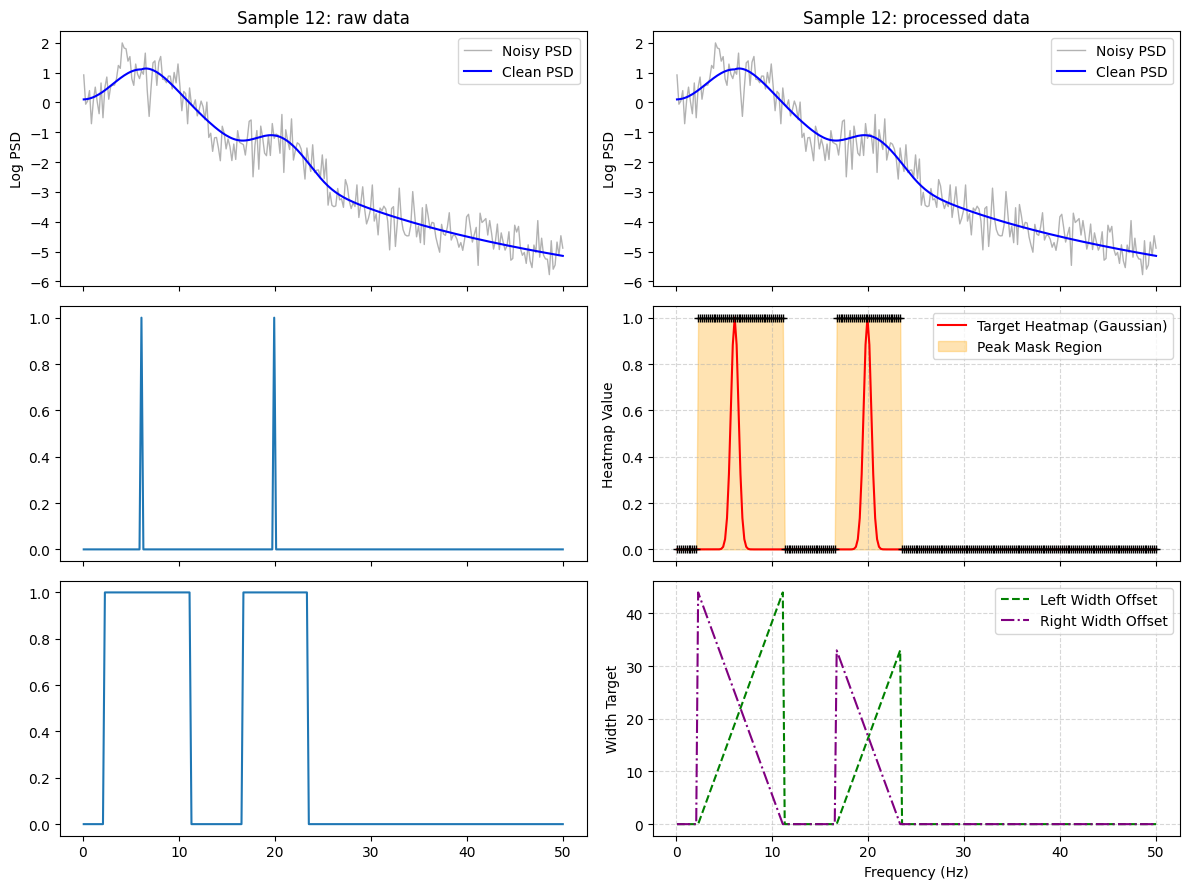

In [ ]:
# select sample index
index = 12

# need to be send back to numpy as it is in tensor
processed_sample = processed_train_ds[index]
processed_psd_noisy       = to_numpy(processed_sample["noisy_psd"])
processed_psd_clean       = to_numpy(processed_sample["clean_psd"])
processed_target_heatmap  = to_numpy(processed_sample["target_heatmap"])
processed_peak_mask       = to_numpy(processed_sample["peak_mask"])

# target_width has shape [2, n_freqs] -> left boundary offset, right boundary offset
processed_target_width     = to_numpy(processed_sample["target_width"]) # NOTE check squeeze insteqd of detqch qs it is the cqse in processing fucntion for inference
processed_left_width       = processed_target_width[0]
processed_right_width      = processed_target_width[1]

# 2. Setup Subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)

# -------------------------------------------------------------------
# Plot 1: Noisy vs Clean PSD Signal
# -------------------------------------------------------------------
axes[0, 0].plot(f, raw_train_psd_noisy[index], label="Noisy PSD", color="gray", alpha=0.6, linewidth=1)
axes[0, 0].plot(f, raw_train_psd_clean[index], label="Clean PSD", color="blue", linewidth=1.5)
axes[0, 0].set_ylabel("Log PSD")
axes[0, 0].set_title(f"Sample {index}: raw data")
axes[0, 0].legend(loc="upper right")

axes[0, 1].plot(f, processed_psd_noisy, label="Noisy PSD", color="gray", alpha=0.6, linewidth=1)
axes[0, 1].plot(f, processed_psd_clean, label="Clean PSD", color="blue", linewidth=1.5)
axes[0, 1].set_ylabel("Log PSD")
axes[0, 1].set_title(f"Sample {index}: processed data")
axes[0, 1].legend(loc="upper right")

# -------------------------------------------------------------------
# Plot 2: Target Heatmap & Detected Peak Positions
# -------------------------------------------------------------------
axes[1, 0].plot(f, raw_train_mask[index][0])

axes[1, 1].plot(f, processed_target_heatmap, label="Target Heatmap (Gaussian)", color="red")
axes[1, 1].plot(f, processed_peak_mask, '+', color="black")
axes[1, 1].fill_between(f, 0, processed_peak_mask, color="orange", alpha=0.3, label="Peak Mask Region")
axes[1, 1].set_ylabel("Heatmap Value")
axes[1, 1].set_ylim(-0.05, 1.05)
axes[1, 1].legend(loc="upper right")
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

# -------------------------------------------------------------------
# Plot 3: Target Width (Boundaries / Offsets)
# -------------------------------------------------------------------
axes[2, 0].plot(f, raw_train_mask[index][1])

axes[2, 1].plot(f, processed_left_width, label="Left Width Offset", color="green", linestyle="--")
axes[2, 1].plot(f, processed_right_width, label="Right Width Offset", color="purple", linestyle="-.")
axes[2, 1].set_xlabel("Frequency (Hz)")
axes[2, 1].set_ylabel("Width Target")
axes[2, 1].legend(loc="upper right")
axes[2, 1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


Visualize forgivness of using heatmap for peak position

--- FOCAL LOSS RESULTS FOR SAMPLE 12 ---
1. Perfect Prediction Loss : 51.539734
2. Slightly Shifted Loss   : 0.967394
3. Missed Peak Loss        : 9.977351


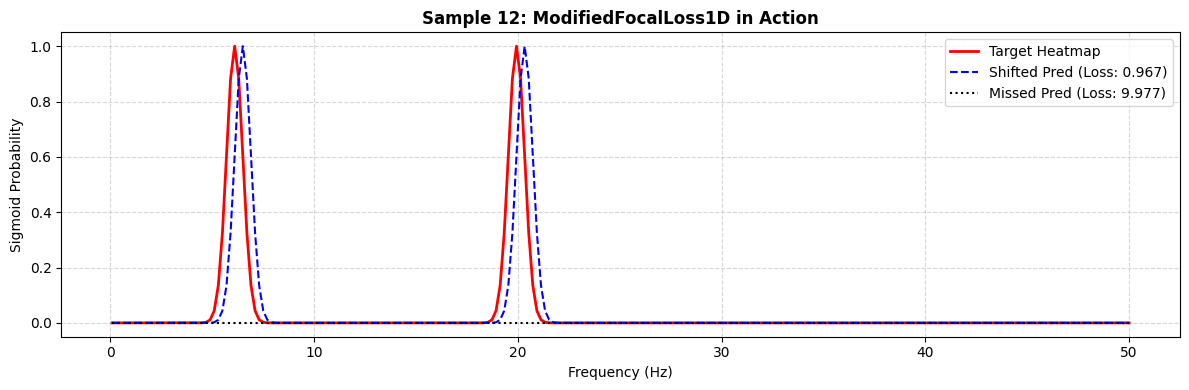

In [ ]:
# Instantiate the Focal Loss
focal_loss_fn = ModifiedFocalLoss1D(alpha=2.0, beta=4.0)

# 1. Prepare Target Heatmap Tensor: Shape [1, 1, n_freqs]
# (Requires batch and channel dimensions for PyTorch)
target_tensor = torch.tensor(
    processed_target_heatmap, dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

# -------------------------------------------------------------------
# SIMULATING MODEL PREDICTIONS (Simulated Logits)
# -------------------------------------------------------------------

# Scenario A: Perfect Prediction (Matches ground truth target exactly)
# Inverse sigmoid (logit) mapping: 1.0 -> +10, 0.0 -> -10
logits_perfect = torch.where(target_tensor > 0.01, 10.0, -10.0)

# Scenario B: Slightly Shifted Peak (Offset by 2 frequency bins)
# Predicts near the peak, but slightly blurred or shifted
# shifted_target = torch.roll(target_tensor, shifts=2, dims=-1)
# logits_shifted = torch.where(shifted_target > 0.01, 5.0, -5.0)

# 1. Clamp target to safe bounds to avoid log(0)
clamped_target = torch.clamp(target_tensor, 1e-6, 1.0 - 1e-6)

# 2. Convert Gaussian heatmap to exact logits via Inverse Sigmoid (logit function)
gaussian_logits = torch.log(clamped_target / (1.0 - clamped_target))

# 3. Shift the Gaussian logits by 2 frequency bins
logits_shifted = torch.roll(gaussian_logits, shifts=2, dims=-1)

# Scenario C: Completely Missed Peak (Predicts 0 everywhere)
logits_missed = torch.full_like(target_tensor, -10.0)


# -------------------------------------------------------------------
# COMPUTE LOSSES
# -------------------------------------------------------------------
loss_perfect = focal_loss_fn(logits_perfect, target_tensor).item()
loss_shifted = focal_loss_fn(logits_shifted, target_tensor).item()
loss_missed = focal_loss_fn(logits_missed, target_tensor).item()

print(f"--- FOCAL LOSS RESULTS FOR SAMPLE {index} ---")
print(f"1. Perfect Prediction Loss : {loss_perfect:.6f}")
print(f"2. Slightly Shifted Loss   : {loss_shifted:.6f}")
print(f"3. Missed Peak Loss        : {loss_missed:.6f}")

# -------------------------------------------------------------------
# VISUALIZE PROBABILITIES VS GROUND TRUTH
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(f, processed_target_heatmap, "r-", label="Target Heatmap", linewidth=2)
ax.plot(
    f,
    torch.sigmoid(logits_shifted).squeeze().numpy(),
    "b--",
    label=f"Shifted Pred (Loss: {loss_shifted:.3f})",
)
ax.plot(
    f,
    torch.sigmoid(logits_missed).squeeze().numpy(),
    "k:",
    label=f"Missed Pred (Loss: {loss_missed:.3f})",
)

ax.set_title(
    f"Sample {index}: ModifiedFocalLoss1D in Action",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Sigmoid Probability")
ax.legend(loc="upper right")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Launch training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Model: Tesla T4


In [ ]:
trained_model, test_metrics, history = train_keypoint_psd_model(
    dataset_path=dataset_path,
    max_epochs=100,
    batch_size=32,
    lr=1e-3
)

Training Keypoint Multi-Task PSD Model on device: cuda
Loading split 'train' from /content/psd_dataset_masks.npz...
 -> Successfully loaded & converted 20000 samples.
Loading split 'val' from /content/psd_dataset_masks.npz...
 -> Successfully loaded & converted 2500 samples.
Loading split 'test' from /content/psd_dataset_masks.npz...
 -> Successfully loaded & converted 2500 samples.
Epoch [01/100] | Train Loss: 1.331025 | Val Loss: 0.869008
{'l_psd': 0.01270003616809845, 'l_grad': 0.0007995273335836828, 'l_curv': 0.0007388246594928205, 'l_heatmap': 0.4539336562156677, 'l_width_peak': 5.247538089752197, 'l_width_bg': 1.2134432792663574}
Epoch [02/100] | Train Loss: 0.956046 | Val Loss: 0.803608
{'l_psd': 0.004719362128525972, 'l_grad': 0.0004174445348326117, 'l_curv': 0.00040978167089633644, 'l_heatmap': 0.4430968165397644, 'l_width_peak': 4.274895191192627, 'l_width_bg': 1.402309536933899}
Epoch [03/100] | Train Loss: 0.914177 | Val Loss: 0.786814
{'l_psd': 0.005736549384891987, 'l_gra

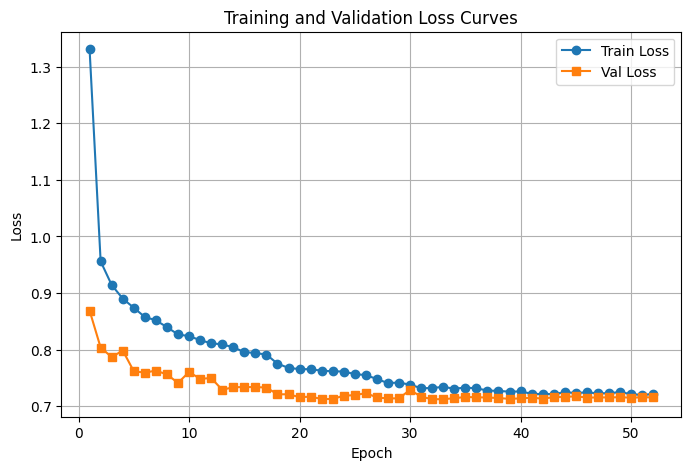

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss", marker="o")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss", marker="s")
plt.title("Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Inference visualization

In [ ]:
def get_OU_signal_exact(T, dt, lbda, omega, sigma):
    """
    Generates a 2D Ornstein-Uhlenbeck signal using the exact discrete-time step
    (matrix exponential solution) with zero numerical damping.
    """
    N = int(T / dt)
    t = np.linspace(0, T, N)

    x = np.zeros(N)
    y = np.zeros(N)

    # 1. Exact transition matrix M = exp(A * dt)
    decay = np.exp(-lbda * dt)
    cos_w = np.cos(omega * dt)
    sin_w = np.sin(omega * dt)

    M = decay * np.array([
        [ cos_w,  sin_w],
        [-sin_w,  cos_w]
    ])

    # 2. Exact standard deviation for discrete noise step
    sigma_eta = sigma * np.sqrt((1.0 - np.exp(-2.0 * lbda * dt)) / lbda)

    # 3. Simulate exact step
    for i in range(1, N):
        # Generate independent Gaussian noise
        eta_x = np.random.normal(0, sigma_eta)
        eta_y = np.random.normal(0, sigma_eta)

        # Matrix multiplication for deterministic state transition
        prev_state = np.array([x[i-1], y[i-1]])
        next_state = M @ prev_state + np.array([eta_x, eta_y])

        x[i] = next_state[0]
        y[i] = next_state[1]

    return t, x

def get_mixed_OU_signals_exact(T, dt, lbda_list, omega_list, sigma_list, factor_list):
    """
    Generates mixed OU signals using the exact solver.
    """
    N = int(T / dt)
    t = np.linspace(0, T, N)
    mixed_OU = np.zeros(N)

    for i in range(len(lbda_list)):
        _, x = get_OU_signal_exact(T, dt, lbda_list[i], omega_list[i], sigma_list[i])
        mixed_OU += x * factor_list[i]

    return t, mixed_OU


--- Running Inference on Simulated Mixed OU Data ---
Loaded Keypoint UNet from 'checkpoints_keypoints/best_keypoint_unet.pth'

--- Model Output Summary ---
Detected Peak Count: 3
 Peak 1: Center = 0.50 Hz | Interval = [0.10 Hz, 1.00 Hz] | Heatmap Score = 0.943
 Peak 2: Center = 9.92 Hz | Interval = [7.38 Hz, 12.82 Hz] | Heatmap Score = 0.951
 Peak 3: Center = 29.96 Hz | Interval = [27.64 Hz, 32.55 Hz] | Heatmap Score = 0.916


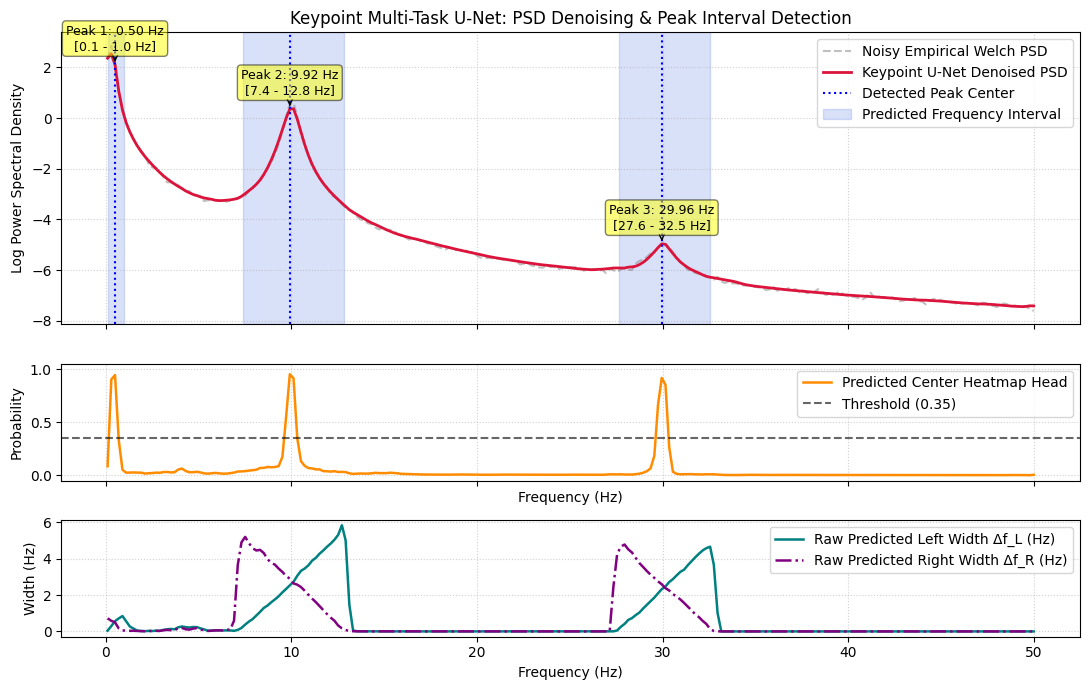

In [ ]:
# =====================================================================
# 1. PEAK & BANDWIDTH DECODER (1D NMS)
# =====================================================================
def decode_keypoint_predictions(
    pred_logits,
    pred_widths,
    f_grid,
    center_thresh=0.35,
    kernel_size=5,
    min_width_bins=0.5,
):
    """Decodes keypoint heatmap logits and predicted width vectors into physical frequencies.

    Args:
        pred_logits: Raw heatmap logits [1, 1, n_freqs] or [1, n_freqs]
        pred_widths: Width predictions [1, 2, n_freqs] or [2, n_freqs]
        f_grid: 1D array of frequency values in Hz
        center_thresh: Sigmoid score threshold for peak detection
        kernel_size: Window size for 1D Non-Maximum Suppression
        min_width_bins: Minimum allowable width in bins (prevents collapse)

    Returns:
        peaks_info: List of dicts containing f0, f_left, f_right, and
        heatmap_score
        probs_np: 1D numpy array of heatmap probabilities
    """
    # 1. Ensure 3D Shape [1, C, N]
    if pred_logits.ndim == 2:
        pred_logits = pred_logits.unsqueeze(0)
    if pred_widths.ndim == 2:
        pred_widths = pred_widths.unsqueeze(0)

    # 2. Apply Sigmoid to heatmap logits
    heatmap_prob = torch.sigmoid(pred_logits)  # Shape: [1, 1, n_freqs]

    # 3. Local Maxima Pooling (1D Non-Maximum Suppression)
    pad = (kernel_size - 1) // 2
    hmax = F.max_pool1d(
        heatmap_prob, kernel_size=kernel_size, stride=1, padding=pad
    )
    keep = (heatmap_prob == hmax) & (heatmap_prob >= center_thresh)

    peak_indices = torch.nonzero(keep.squeeze()).squeeze(-1)

    probs_np = heatmap_prob.squeeze().detach().cpu().numpy()

    # Early exit if no peaks found
    if peak_indices.numel() == 0:
        return [], probs_np

    if peak_indices.ndim == 0:
        peak_indices = peak_indices.unsqueeze(0)

    peak_indices = peak_indices.detach().cpu().numpy()

    # Frequency bin step size (df in Hz)
    df = f_grid[1] - f_grid[0] if len(f_grid) > 1 else 1.0

    # Ensure widths are positive (apply ReLU if needed)
    widths_clamped = torch.relu(pred_widths).squeeze().detach().cpu().numpy()

    peaks_info = []

    for idx in peak_indices:
        f0 = f_grid[idx]
        score = probs_np[idx]

        # Read predicted left/right bin widths and clamp to min threshold
        left_bins = max(widths_clamped[0, idx], min_width_bins)
        right_bins = max(widths_clamped[1, idx], min_width_bins)

        # Convert bin offsets into Hz bounds
        f_left = max(f_grid[0], f0 - (left_bins * df))
        f_right = min(f_grid[-1], f0 + (right_bins * df))

        peaks_info.append({
            "idx": int(idx),
            "f0": float(f0),
            "f_left": float(f_left),
            "f_right": float(f_right),
            "bandwidth_hz": float(f_right - f_left),
            "left_bins": float(left_bins),
            "right_bins": float(right_bins),
            "score": float(score),
        })

    return peaks_info, probs_np
# =====================================================================
# 2. KEYPOINT RESULT VISUALIZER
# =====================================================================

def plot_keypoint_psd_inference(f_grid, log_noisy, pred_clean, peaks_info, heatmap_prob, left_width, right_width):
    """
    Plots the empirical noisy log PSD, the network's clean curve reconstruction,
    the continuous 1D peak heatmap, and the detected peak center/interval regions.
    """
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 7), sharex=True, gridspec_kw={'height_ratios': [2.5, 1, 1]})

    # --- Top Subplot: PSD Curves and Peak Bounds ---
    ax1.plot(f_grid, log_noisy, label="Noisy Empirical Welch PSD", color="gray", alpha=0.5, linestyle="--")
    ax1.plot(f_grid, pred_clean, label="Keypoint U-Net Denoised PSD", color="crimson", linewidth=2.0)

    # Draw detected peak centers and interval bounds
    for i, p in enumerate(peaks_info):
        # Vertical line for Peak Center (f0)
        ax1.axvline(x=p["f0"], color="blue", linestyle=":", linewidth=1.5,
                    label="Detected Peak Center" if i == 0 else "")

        # Shaded frequency interval [f_left, f_right]
        ax1.axvspan(p["f_left"], p["f_right"], color="royalblue", alpha=0.2,
                    label="Predicted Frequency Interval" if i == 0 else "")

        # Annotation text
        peak_y = pred_clean[p["idx"]]
        ax1.annotate(
            f"Peak {i+1}: {p['f0']:.2f} Hz\n[{p['f_left']:.1f} - {p['f_right']:.1f} Hz]",
            xy=(p["f0"], peak_y),
            xytext=(p["f0"], peak_y + 0.6),
            ha='center',
            arrowprops=dict(arrowstyle="->", color="black", lw=1),
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5)
        )

    ax1.set_ylabel("Log Power Spectral Density")
    ax1.set_title("Keypoint Multi-Task U-Net: PSD Denoising & Peak Interval Detection")
    ax1.grid(True, linestyle=":", alpha=0.6)
    ax1.legend(loc="upper right")

    # --- Bottom Subplot: Predicted Center Heatmap ---
    ax2.plot(f_grid, heatmap_prob, color="darkorange", linewidth=1.8, label="Predicted Center Heatmap Head")
    ax2.axhline(y=0.35, color="black", linestyle="--", alpha=0.6, label="Threshold (0.35)")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Probability")
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, linestyle=":", alpha=0.6)
    ax2.legend(loc="upper right")

    ax3.plot(f_grid, left_width, color="teal", linewidth=1.8, label="Raw Predicted Left Width Δf_L (Hz)")
    ax3.plot(f_grid, right_width, color="purple", linewidth=1.8, linestyle="-.", label="Raw Predicted Right Width Δf_R (Hz)")
    ax3.set_xlabel("Frequency (Hz)")
    ax3.set_ylabel("Width (Hz)")
    ax3.grid(True, linestyle=":", alpha=0.6)
    ax3.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


# =====================================================================
# 3. MODEL LOAD & INFERENCE EXECUTION SCRIPT
# =====================================================================

def load_keypoint_model(checkpoint_path="checkpoints_keypoints/best_keypoint_unet.pth", base_filters=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file '{checkpoint_path}' not found!")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    # model = MultiTaskUNet1D(in_channels=1, base_filters=base_filters).to(device)
    model = ResMultiTaskUNet1D(in_channels=1, base_filters=base_filters).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print(f"Loaded Keypoint UNet from '{checkpoint_path}'")
    return model, device


if __name__ == "__main__":
    CHECKPOINT_PATH = "checkpoints_keypoints/best_keypoint_unet.pth"

    # --- Settings ---
    USE_SIMULATED = True   # Toggle False for real EEG recording
    TARGET_N_FREQS = 250   # Matches training resolution
    TARGET_F_MAX = 50.0    # Frequency ceiling (50 Hz)

    if USE_SIMULATED:
        print("\n--- Running Inference on Simulated Mixed OU Data ---")
        T = 1000  # Signal duration (s)
        dt = 0.001
        fs = 1 / dt

        lbda_list = [1, 2, 5]
        omega_list = [2 * np.pi * 0.3, 2 * np.pi * 10, 2 * np.pi * 30]
        sigma_list = [3, 2, 50]
        factor_list = [1, 1, 0.005]

        # Generate simulated signal
        t, y = get_mixed_OU_signals_exact(T, dt, lbda_list, omega_list, sigma_list, factor_list)

    else:
        print("\n--- Running Keypoint Inference on Real EEG Recording File ---")
        file = r"c:\Users\holcman\Documents\GitHub\EEG-labellisation-app---Spectrogram\anesthesia_database\rec_20240321_085300.npy"
        fs = 128
        y = np.load(file)
        y = y[2100 * fs : 2250 * fs]  # Extract 150 second slice
        t = np.arange(len(y)) / fs

    # --- Compute Empirical PSD via Welch's Method ---
    nperseg = int(8 * fs)
    f_emp, psd_emp = signal.welch(y, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)

    # Restrict to [0.1, 50 Hz]
    freq_mask = (f_emp >= 0.1) & (f_emp <= TARGET_F_MAX)
    f_emp = f_emp[freq_mask]
    psd_emp = psd_emp[freq_mask]

    # Resample onto model grid (n_freqs = 250)
    f_grid = np.linspace(0.1, TARGET_F_MAX, TARGET_N_FREQS)
    log_psd_emp = np.log(psd_emp + 1e-12)
    resampled_log_psd = np.interp(f_grid, f_emp, log_psd_emp)

    # Format input tensor [1, 1, n_freqs]
    input_tensor = torch.tensor(resampled_log_psd, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    # --- RUN INFERENCE ---
    model, device = load_keypoint_model(CHECKPOINT_PATH, base_filters=32)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        pred_clean_tensor, pred_logits, pred_widths = model(input_tensor)

    # Extract NumPy predictions
    pred_clean_arr = pred_clean_tensor.squeeze().cpu().numpy()

    # Decode Heatmaps and Widths into peak information
    peaks_info, heatmap_prob = decode_keypoint_predictions(
        pred_logits, pred_widths, f_grid, center_thresh=0.35
    )

    # Extract Raw Width Channels from Head 3 (Shape: [2, n_freqs])
    raw_widths = pred_widths.squeeze().cpu().numpy()
    df = f_grid[1] - f_grid[0]  # Frequency bin resolution in Hz

    # Convert raw width predictions from "number of bins" to "Hz"
    raw_left_width_hz  = raw_widths[0, :] * df   # Channel 0: Left Width (Hz)
    raw_right_width_hz = raw_widths[1, :] * df   # Channel 1: Right Width (Hz)

    # Print Summary Logs
    print(f"\n--- Model Output Summary ---")
    print(f"Detected Peak Count: {len(peaks_info)}")
    for i, p in enumerate(peaks_info):
        print(f" Peak {i+1}: Center = {p['f0']:.2f} Hz | Interval = [{p['f_left']:.2f} Hz, {p['f_right']:.2f} Hz] | Heatmap Score = {p['score']:.3f}")

    # --- VISUALIZE RESULTS ---
    plot_keypoint_psd_inference(
        f_grid=f_grid,
        log_noisy=resampled_log_psd,
        pred_clean=pred_clean_arr,
        peaks_info=peaks_info,
        heatmap_prob=heatmap_prob,
        left_width = raw_left_width_hz,
        right_width = raw_right_width_hz
    )